<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #38668d, #46a6ab);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">🛠️ Exploratory Data Analysis (EDA)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
The dataset underwent a comprehensive preprocessing pipeline to ensure quality and consistency. 
Missing values were handled appropriately, categorical variables were encoded into machine-readable formats, 
and numerical features were scaled to standardize their ranges. These steps improved data integrity and 
helped optimize downstream model performance.
</p>

</div>

</div>

- Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

sns.set_theme()

- Load Data

In [2]:
df = pd.read_csv("../data/House Prices Dataset.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


- Understanding the Data

In [3]:
print("Shape:", df.shape)

Shape: (1460, 81)


In [4]:
print("Columns:")
df.columns

Columns:


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond  

In [6]:
print("Describe:")
df.describe()

Describe:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


- Missing Values

Missing Values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


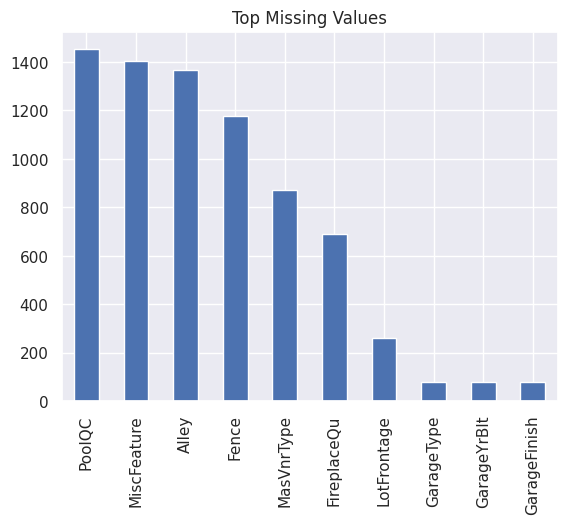

In [7]:
missing = df.isnull().sum()

# show the columns that have nulls
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing Values:")
print(missing)

# Simple plot to show the number of nulls in every column 
missing.head(10).plot(kind="bar")
plt.title("Top Missing Values")
plt.show()

- Distribution (Target Variable => price)

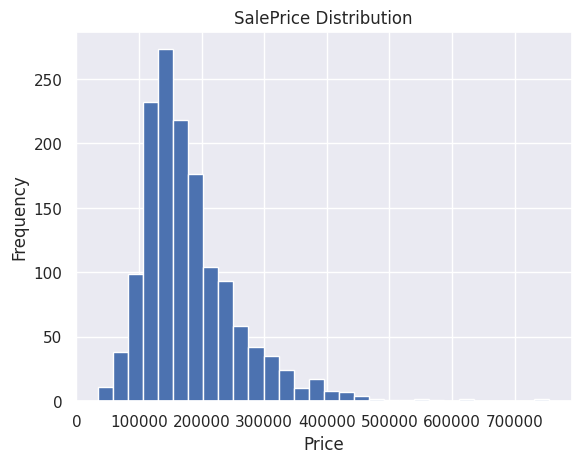

In [8]:
plt.hist(df["SalePrice"], bins=30)
plt.title("SalePrice Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

- Correlation


To show the relationship between features and the price (target)

Top 20 Correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64


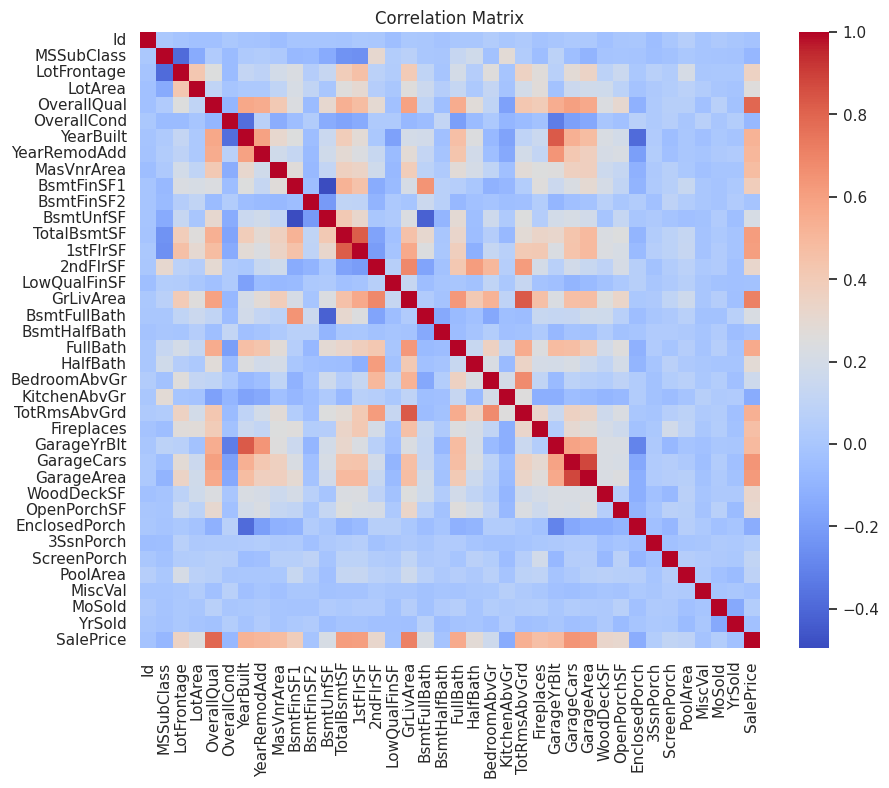

In [9]:
corr = df.corr(numeric_only=True)

# أعلى correlation مع السعر
top_corr = corr["SalePrice"].sort_values(ascending=False)

print("Top 20 Correlations with SalePrice:")
print(top_corr.head(20))

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

- Visualization => The relation between the important features and the price (target)


1- Overall Quality vs Price

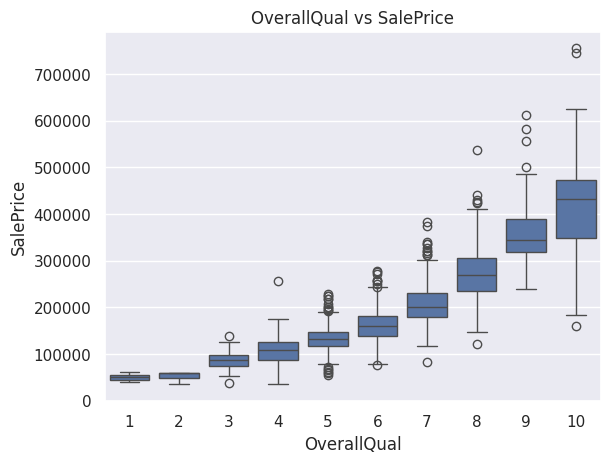

In [10]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.title("OverallQual vs SalePrice")
plt.show()

the relationship here is when the Quality increse the price increace and the boxplot show that correctly 

2- Living Area vs Price

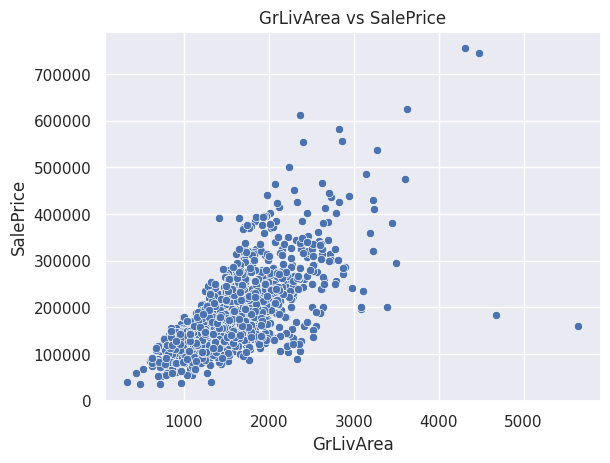

In [11]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("GrLivArea vs SalePrice")
plt.show()

the relationship here is when the Area increse the price increace and the scatter show that correctly 

## 3- Garage vs Price

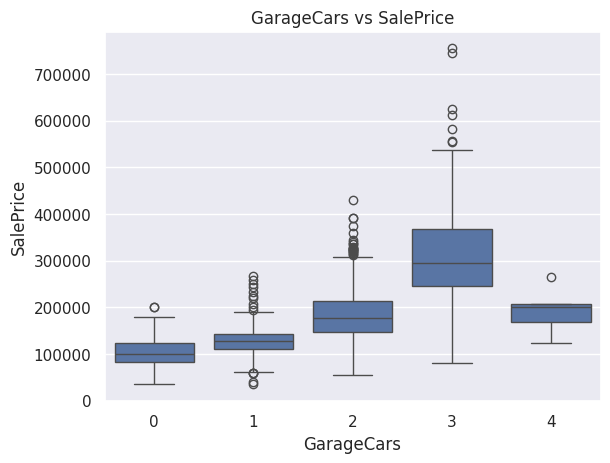

In [12]:
sns.boxplot(x="GarageCars", y="SalePrice", data=df)
plt.title("GarageCars vs SalePrice")
plt.show()

<div style="font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #4facfe, #00f2fe);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2>🧹 Preprocessing Section</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="font-size:17px; color:#2c3e50;">
Data was cleaned, missing values handled, categorical features encoded, and numerical features scaled to prepare the dataset for modeling.
</p>

</div>

</div>

In [13]:
df = pd.read_csv('../data/House Prices Dataset.csv')
print(f'rows : {df.shape[0]} || columns : {df.shape[1]}')
print(f'nulls in Price target column : {df['SalePrice'].isna().sum()} ')

rows : 1460 || columns : 81
nulls in Price target column : 0 


In [14]:

kitchen_andExter_order = [['Fa','TA','Gd','Ex'] , ['Fa','TA','Gd','Ex'] ] # ordinal data (ranks)

# ================= cat data ======================== 

cat_features_all = [
    'Neighborhood',
    'HouseStyle',
    'Foundation',
    'KitchenQual',
    'ExterQual'
]


cat_features_ohe = [
    'Neighborhood',
    'HouseStyle',
    'Foundation', ]


cat_features_ordencd = [
   'KitchenQual',
    'ExterQual'
     ]


In [15]:
# ================== correlation ======================== 
corr = df.corr(numeric_only=True)
top_corr = corr["SalePrice"].sort_values(ascending=False).reset_index()

# top 5 categorical columns 
print("Top 15 Correlations with SalePrice:")
print(top_corr.head(16))
numeric_data = top_corr.head(16).iloc[:,0].tolist()



Top 15 Correlations with SalePrice:
           index  SalePrice
0      SalePrice   1.000000
1    OverallQual   0.790982
2      GrLivArea   0.708624
3     GarageCars   0.640409
4     GarageArea   0.623431
5    TotalBsmtSF   0.613581
6       1stFlrSF   0.605852
7       FullBath   0.560664
8   TotRmsAbvGrd   0.533723
9      YearBuilt   0.522897
10  YearRemodAdd   0.507101
11   GarageYrBlt   0.486362
12    MasVnrArea   0.477493
13    Fireplaces   0.466929
14    BsmtFinSF1   0.386420
15   LotFrontage   0.351799


In [16]:
# ================= dropping  ====================== 
all_data = cat_features_all + numeric_data
df = df[all_data ]
print('data after droping unesential columns : ')
print(f'rows : {df.shape[0]} || columns : {df.shape[1]}')

data after droping unesential columns : 
rows : 1460 || columns : 21


In [17]:
# ============== unique values checking ===================== 
for i in cat_features_all :
    print(f'unique values in {i} column : {df[i].unique()}')
    print(f'unique values number in {i} column : {df[i].nunique()}')

unique values in Neighborhood column : <StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str
unique values number in Neighborhood column : 25
unique values in HouseStyle column : <StringArray>
['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
Length: 8, dtype: str
unique values number in HouseStyle column : 8
unique values in Foundation column : <StringArray>
['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab', 'Stone']
Length: 6, dtype: str
unique values number in Foundation column : 6
unique values in KitchenQual column : <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str
unique values number in KitchenQual column : 4
unique values in ExterQual column : <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Len

In [18]:
# ================ Splitting ========================== 
X = df.drop('SalePrice' , axis=1)
y = df['SalePrice']
x_tr , x_test , y_tr , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 40)

print(f'shape of train data {x_tr.shape}')
print(f'shape of test data {x_test.shape}')

shape of train data (1168, 20)
shape of test data (292, 20)


In [19]:
int_data = []
float_data = []
for i in numeric_data :
    if i != 'SalePrice' : # sale price now is the target we must skip it from loop (it's not in x_tr)
        typee = x_tr[i].dtype
        print(f'{i} : {typee} ')
        if typee == 'int64' :
            int_data.append(i)
        else :
            float_data.append(i)

print(f'int data : {int_data} \n {x_tr[int_data]}' )
print(f'float data : {float_data} \n {x_tr[float_data]}' )
# now i know that all data is int the float is just a number .0

OverallQual : int64 
GrLivArea : int64 
GarageCars : int64 
GarageArea : int64 
TotalBsmtSF : int64 
1stFlrSF : int64 
FullBath : int64 
TotRmsAbvGrd : int64 
YearBuilt : int64 
YearRemodAdd : int64 
GarageYrBlt : float64 
MasVnrArea : float64 
Fireplaces : int64 
BsmtFinSF1 : int64 
LotFrontage : float64 
int data : ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'Fireplaces', 'BsmtFinSF1'] 
       OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  1stFlrSF  \
609             4       1029           1         261         1029      1029   
1361            7       1530           2         430         1530      1530   
1076            5       1466           2         566          796      1096   
1138            6       1567           2         714         1567      1567   
1159            6       1876           2         540          901       943   
...           ...        ...        

In [20]:
median_cols = [
    'LotFrontage',
    'MasVnrArea',
    'GarageYrBlt',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'BsmtFinSF1',
    'YearBuilt',
    'YearRemodAdd'
]

mode_cols = [
    'GarageCars',
    'FullBath',
    'TotRmsAbvGrd',
    'Fireplaces',
    'OverallQual'
]
print(f'data to be imputed with mode : \n {df[mode_cols]}') # mode is better with those columns 

for i in median_cols : 
   print(f'{i} column value counts \n {df[i].value_counts()} \n ============================================== \n')

data to be imputed with mode : 
       GarageCars  FullBath  TotRmsAbvGrd  Fireplaces  OverallQual
0              2         2             8           0            7
1              2         2             6           1            6
2              2         2             6           1            7
3              3         1             7           1            7
4              3         2             9           1            8
...          ...       ...           ...         ...          ...
1455           2         2             7           1            6
1456           2         2             7           2            6
1457           1         2             9           2            7
1458           1         1             5           0            5
1459           1         1             6           0            5

[1460 rows x 5 columns]
LotFrontage column value counts 
 LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1


In [21]:
print('train data : ')
x_tr.head()

train data : 


,Neighborhood,HouseStyle,Foundation,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage
609,Sawyer,1Story,CBlock,TA,TA,4,1029,1,261,1029,1029,1,5,1961,1961,1961.0,192.0,0,903,61.0
1361,StoneBr,1Story,PConc,Gd,Gd,7,1530,2,430,1530,1530,2,7,2005,2005,2005.0,16.0,1,1274,124.0
1076,OldTown,1.5Fin,CBlock,Gd,TA,5,1466,2,566,796,1096,2,7,1936,1989,1950.0,0.0,1,626,60.0
1138,Mitchel,1Story,PConc,Gd,TA,6,1567,2,714,1567,1567,2,5,1977,1977,1977.0,0.0,2,1567,NaN
1159,NWAmes,2Story,CBlock,Gd,Gd,6,1876,2,540,901,943,2,8,1974,1974,1974.0,270.0,1,442,76.0


In [22]:
print('test data : ')
x_test.head()

test data : 


,Neighborhood,HouseStyle,Foundation,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage
1258,Gilbert,SLvl,PConc,Gd,Gd,7,1166,2,400,856,1166,2,5,2005,2005,2005.0,182.0,0,655,59.0
1041,NWAmes,2Story,CBlock,Gd,TA,6,1632,2,484,800,800,1,7,1966,2000,1966.0,252.0,0,400,NaN
1181,Crawfor,1Story,PConc,Gd,Ex,8,1652,2,482,1600,1652,2,5,2008,2008,2008.0,186.0,1,1480,64.0
1108,Gilbert,2Story,PConc,TA,TA,6,1690,2,463,924,948,2,7,2000,2000,2000.0,0.0,1,0,NaN
554,NridgHt,2Story,PConc,Gd,Gd,7,2046,3,871,998,1006,2,8,2003,2004,2003.0,292.0,1,866,85.0


In [23]:
std_scaler = StandardScaler()


simple_median = SimpleImputer(strategy='median')

x_tr[median_cols] = simple_median.fit_transform(x_tr[median_cols])
x_test[median_cols] = simple_median.transform(x_test[median_cols])

simple_mode = SimpleImputer(strategy='most_frequent')

x_tr[mode_cols] = simple_mode.fit_transform(x_tr[mode_cols])
x_test[mode_cols] = simple_mode.transform(x_test[mode_cols])
print('data which imputed with mode:')
x_tr[mode_cols].head()

data which imputed with mode:


,GarageCars,FullBath,TotRmsAbvGrd,Fireplaces,OverallQual
609,1,1,5,0,4
1361,2,2,7,1,7
1076,2,2,7,1,5
1138,2,2,5,2,6
1159,2,2,8,1,6


In [24]:
# check categorical data before encoding 
print(f'nulls in categorical data : \n {df[cat_features_all].isna().sum()}')

nulls in categorical data : 
 Neighborhood    0
HouseStyle      0
Foundation      0
KitchenQual     0
ExterQual       0
dtype: int64


In [25]:
ord_encoder = OrdinalEncoder(categories=kitchen_andExter_order)
x_tr[['KitchenQual' , 'ExterQual']] = ord_encoder.fit_transform(x_tr[['KitchenQual' , 'ExterQual']])
x_test[['KitchenQual' , 'ExterQual']] = ord_encoder.transform(x_test[['KitchenQual' , 'ExterQual']])

print('shape before OHE (one-hot encoding)\n')
print(x_tr.shape)
print(x_test.shape , end= '\n\n')

shape before OHE (one-hot encoding)

(1168, 20)
(292, 20)



In [26]:
x_tr = pd.get_dummies(x_tr, columns = cat_features_ohe , dtype=int)
x_test = pd.get_dummies(x_test, columns = cat_features_ohe, dtype= int)
x_test = x_test.reindex(columns=x_tr.columns, fill_value=0) 
'''
 the columns must be same to prevent model error so any column not in test i must put it
 with default value = 0 

'''
print('shape after OHE (one-hot encoding) \n ')
print(x_tr.shape)
print(x_test.shape  ,end='\n\n')

shape after OHE (one-hot encoding) 
 
(1168, 56)
(292, 56)



In [27]:
for i in numeric_data :
   if i != 'SalePrice':
    Q1 = x_tr[i].quantile(0.25)
    Q3 = x_tr[i].quantile(0.75)
    IQR = Q3 - Q1 
    up_bound = Q3 + 1.5 * IQR
    low_bound = Q1 - 1.5 * IQR
    print(f'outliers in {i} column : ' , end= '')
    print(x_tr[ (x_tr[i] > up_bound) | (x_tr[i] < low_bound)  ][i].count())

    # clipping data and cast to int because upper or lower bound may be float
    x_tr[i] = x_tr[i].clip(low_bound, up_bound).astype(int)
    x_test[i] = x_test[i].clip(low_bound , up_bound).astype(int)

outliers in OverallQual column : 2
outliers in GrLivArea column : 21
outliers in GarageCars column : 4
outliers in GarageArea column : 16
outliers in TotalBsmtSF column : 52
outliers in 1stFlrSF column : 15
outliers in FullBath column : 0
outliers in TotRmsAbvGrd column : 26
outliers in YearBuilt column : 5
outliers in YearRemodAdd column : 0
outliers in GarageYrBlt column : 0
outliers in MasVnrArea column : 76
outliers in Fireplaces column : 5
outliers in BsmtFinSF1 column : 5
outliers in LotFrontage column : 87


In [41]:
print('Train data : ')
x_tr.head()

Train data : 


,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
609,1.0,1.0,4,-0.981103,1,-0.994673,-0.054107,-0.358329,1,5,...,0,0,0,0,0,1,0,0,0,0
1361,2.0,2.0,7,0.058420,2,-0.185045,1.192701,1.019965,2,7,...,0,0,0,0,0,0,1,0,0,0
1076,2.0,1.0,5,-0.074373,2,0.466490,-0.633959,-0.174006,2,7,...,0,0,0,0,0,1,0,0,0,0
1138,2.0,1.0,6,0.135192,2,1.175513,1.284780,1.121755,2,5,...,0,0,0,0,0,0,1,0,0,0
1159,2.0,2.0,6,0.776335,2,0.341932,-0.372652,-0.594922,2,8,...,0,1,0,0,0,1,0,0,0,0


In [29]:
print(f'nulls in train data after imputation : \n {x_tr.isna().sum()}')

nulls in train data after imputation : 
 KitchenQual             0
ExterQual               0
OverallQual             0
GrLivArea               0
GarageCars              0
GarageArea              0
TotalBsmtSF             0
1stFlrSF                0
FullBath                0
TotRmsAbvGrd            0
YearBuilt               0
YearRemodAdd            0
GarageYrBlt             0
MasVnrArea              0
Fireplaces              0
BsmtFinSF1              0
LotFrontage             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer    

In [40]:
print('Test data : ')
x_test.head()

Test data : 


,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
1258,2.0,2.0,7,-0.696842,2,-0.328766,-0.484641,0.018570,2,5,...,0,0,0,1,0,0,1,0,0,0
1041,2.0,1.0,6,0.270060,2,0.073653,-0.624004,-0.988327,1,7,...,0,1,0,0,0,1,0,0,0,0
1181,2.0,3.0,8,0.311558,2,0.064071,1.366905,1.355597,2,5,...,0,0,0,0,0,0,1,0,0,0
1108,1.0,1.0,6,0.390404,2,-0.026952,-0.315413,-0.581167,2,7,...,0,1,0,0,0,0,1,0,0,0
554,2.0,2.0,7,1.129067,3,1.927653,-0.131254,-0.421604,2,8,...,0,1,0,0,0,0,1,0,0,0


In [31]:
print(f'nulls in test data after imputation : \n {x_test.isna().sum()}')

nulls in test data after imputation : 
 KitchenQual             0
ExterQual               0
OverallQual             0
GrLivArea               0
GarageCars              0
GarageArea              0
TotalBsmtSF             0
1stFlrSF                0
FullBath                0
TotRmsAbvGrd            0
YearBuilt               0
YearRemodAdd            0
GarageYrBlt             0
MasVnrArea              0
Fireplaces              0
BsmtFinSF1              0
LotFrontage             0
Neighborhood_Blmngtn    0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     

In [39]:
print('range of mode columns (which imputed with mode)')
print(f'{df[mode_cols].max() - df[mode_cols].min()}')
scaled_cols = median_cols

'''
only scale columns which imputed with median because there values are big
'''

x_tr[scaled_cols] = std_scaler.fit_transform(x_tr[scaled_cols])
x_test[scaled_cols] = std_scaler.transform(x_test[scaled_cols])


print('train data after scaling : \n')
x_tr.head()

range of mode columns (which imputed with mode)
GarageCars       4
FullBath         3
TotRmsAbvGrd    12
Fireplaces       3
OverallQual      9
dtype: int64
train data after scaling : 



,KitchenQual,ExterQual,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,...,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood
609,1.0,1.0,4,-0.981103,1,-0.994673,-0.054107,-0.358329,1,5,...,0,0,0,0,0,1,0,0,0,0
1361,2.0,2.0,7,0.058420,2,-0.185045,1.192701,1.019965,2,7,...,0,0,0,0,0,0,1,0,0,0
1076,2.0,1.0,5,-0.074373,2,0.466490,-0.633959,-0.174006,2,7,...,0,0,0,0,0,1,0,0,0,0
1138,2.0,1.0,6,0.135192,2,1.175513,1.284780,1.121755,2,5,...,0,0,0,0,0,0,1,0,0,0
1159,2.0,2.0,6,0.776335,2,0.341932,-0.372652,-0.594922,2,8,...,0,1,0,0,0,1,0,0,0,0


<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #ff7e5f, #feb47b);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">⚙️ Multiple Linear Regression (Gradient Descent)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
This implementation applies Multiple Linear Regression using Gradient Descent, an iterative optimization algorithm. 
Instead of solving the model analytically, the coefficients are updated step-by-step by minimizing the cost function. 
At each iteration, gradients are computed to adjust the weights in the direction that reduces prediction error, 
making this approach scalable and suitable for higher-dimensional datasets.
</p>

</div>

</div>

In [33]:
class MultipleLinearRegressionGD:
    
    def __init__(self):
        self.B_0 = None
        self.B = None   # vector of weights
        self.SSE = float('inf')
        self.MSE = None
    

    def fit(self, X, y, learning_rate=0.01, epochs=1000, tolerance=1e-6):

        self.X = np.array(X)
        self.y = np.array(y)
        self.n = len(self.y)
        self.m = self.X.shape[1]   # number of features

        # initialize parameters
        self.B_0 = 0
        self.B = np.zeros(self.m)

        self.SSE = float('inf')

        for _ in range(epochs):

            # prediction
            y_hat = self.B_0 + np.dot(self.X, self.B)

            # error
            error = self.y - y_hat

            # gradients
            dB_0 = (-2 / self.n) * np.sum(error)
            dB = (-2 / self.n) * np.dot(self.X.T, error)

            # update parameters
            self.B_0 -= learning_rate * dB_0
            self.B -= learning_rate * dB

            # SSE
            new_sse = np.sum((self.y - (self.B_0 + np.dot(self.X, self.B))) ** 2)

            if abs(self.SSE - new_sse) < tolerance:
                self.SSE = new_sse
                break

            self.SSE = new_sse

        self.MSE = self.SSE / self.n

    def predict(self, X):

        X = np.array(X)
        return self.B_0 + np.dot(X, self.B)

    def plot(self, X, y):

        if self.B_0 is None or self.B is None:
            raise ValueError("Model not trained yet")

        X = np.array(X)
        y = np.array(y)

        y_pred = self.predict(X)

    

       
        plt.scatter(y, y_pred, color='blue')
        plt.plot([y.min(), y.max()],
                [y.min(), y.max()],
                color='red')

        plt.xlabel("Actual y")
        plt.ylabel("Predicted y")
        plt.title("Actual vs Predicted (Multiple Linear Regression)")
        plt.show()

In [34]:
model = MultipleLinearRegressionGD()
model.fit(x_tr,y_tr,0.001,1000)

In [35]:
y_pred = model.predict(x_test)
print("Evaluation of the model")
print("------------------------")

print(f"Intercept (B0): {round(model.B_0, 3)}")
print(f"Weights (B): {model.B}")
print(f"Mean squared error is: {round(model.MSE, 3)}")
X = model.MSE
print(f'root(x)')

Evaluation of the model
------------------------
Intercept (B0): 895.772
Weights (B): [ 8.12972195e+03  6.94038440e+03  1.72391470e+04  9.71787566e+03
  4.69787157e+03  4.36678430e+03  7.94909874e+03  5.92166472e+03
  2.56403260e+03  5.68514137e+03  2.89293109e+03  3.69179602e+03
  8.67115153e+02  2.46995405e+03  5.89151210e+03  1.07294599e+04
  4.37464122e+03 -6.76000690e+02  1.03641045e+01 -3.56370443e+02
  1.01140304e+03  7.79230641e+02 -1.59083557e+03  1.18588346e+03
 -8.20203047e+02 -4.85970966e+02 -1.94987184e+02  8.94443889e+01
 -5.39897705e+02 -1.54169616e+03 -1.36825420e+02 -1.31773844e+03
  3.00641483e+03  2.59281856e+03 -1.28329933e+03 -1.78965071e+02
 -4.70920683e+02 -7.83342404e+02  1.28681810e+02  1.84609193e+03
  1.20368884e+02  5.02123826e+02  3.97077965e+02  1.74923003e+02
 -1.08987271e+03  1.30226556e+02 -1.38061090e+02  1.71899183e+03
 -4.72542133e+01 -2.50258984e+02 -4.57167347e+02 -9.17651519e+02
  2.37841883e+03  3.83402131e+00 -1.25335539e+02  1.36739079e+01]
Mea

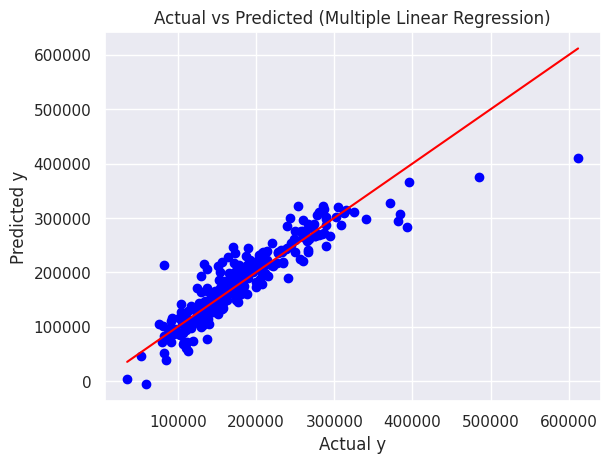

In [36]:
model.plot(x_test, y_test)

## TASK 5 

<div style="
    font-family:Arial;
    width:95%;
    max-width:1500px;
">

<!-- SECTION TITLE -->
<div style="
    padding:15px;
    border-radius:10px;
    background: linear-gradient(135deg, #539469, #364e4a);
    color:white;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.2);
">
    <h2 style="margin:0;">📈 Simple Linear Regression (Numerical Approach)</h2>
</div>

<br>

<!-- CONTENT BOX -->
<div style="
    padding:20px;
    border-radius:12px;
    background:#f8f9fa;
    box-shadow: 0px 5px 15px rgba(0,0,0,0.15);
">

<p style="
    font-size:17px;
    color:#2c3e50;
    line-height:1.6;
    margin:0;
">
This implementation demonstrates Simple Linear Regression using a direct numerical solution rather than iterative training. 
The model parameters are computed analytically through summations, normal equations, and basic linear algebra operations. 
This approach provides a clear and efficient way to understand how regression coefficients are derived mathematically.
</p>

</div>

</div>

In [37]:
class SimpleLinearRegressionNumericalView:
    def __init__(self):
        self.a0 = None
        self.a1 = None
        self.SSE = None
        self.MSE = None

    def predict(self, X):
        X = np.asarray(X, dtype=float).reshape(-1)
        return self.a0 + self.a1 * X

    @staticmethod
    def sse(y, y_hat):
        return np.sum((y - y_hat) ** 2)

    def fit(self, X, y, show_steps=True):
      
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        n = len(X)

        # 1. Compute Summations
        Sx = np.sum(X)
        Sy = np.sum(y)
        Sxx = np.sum(X ** 2)
        Sxy = np.sum(X * y)

        if show_steps:
            print("Step 1: Define SSE (Sum of Squared Errors)")
            print("SSE = Σ(yi - a0 - a1*xi)^2\n")
            
            print("Step 2: Compute Summations")
            print(f"n = {n}")
            print(f"Σxi = {Sx:,.2f}")
            print(f"Σyi = {Sy:,.2f}")
            print(f"Σxi^2 = {Sxx:,.2f}")
            print(f"Σxiyi = {Sxy:,.2f}\n")
            
            print("Step 3: Matrix Form (Normal Equations)")
            print(f"[[ {n}   {Sx:,.2f} ]] [[ a0 ]]   [[ {Sy:,.2f} ]]")
            print(f"[[ {Sx:,.2f}   {Sxx:,.2f} ]] [[ a1 ]] = [[ {Sxy:,.2f} ]]\n")

        # Build Matrix and Solve
        A = np.array([[n, Sx], [Sx, Sxx]], dtype=float)
        b = np.array([Sy, Sxy], dtype=float)
        
        # Solving using Cramer's rule or linalg.solve
        self.a0, self.a1 = np.linalg.solve(A, b)

        if show_steps:
            print("Step 4: Solve the System")
            print(f"a0 (Intercept) = {self.a0:.4f}")
            print(f"a1 (Slope) = {self.a1:.4f}\n")

        # Final Evaluation
        y_hat = self.predict(X)
        self.SSE = self.sse(y, y_hat)
        self.MSE = self.SSE / n

        if show_steps:
            print("Final Model Results:")
            print(f"Equation: ŷ = {self.a0:.4f} + {self.a1:.4f} * x")
            print(f"SSE = {self.SSE:,.2f}")
            print(f"MSE = {self.MSE:,.2f}")
        
        return self

- Apply the Model on a specific feature vs the target feature (Sale Price)

In [38]:
feature_name = 'GrLivArea' 

print(f"Training Simple Linear Regression for: {feature_name} vs SalePrice\n")
NumericalModel = SimpleLinearRegressionNumericalView()


NumericalModel.fit(x_tr[feature_name], y_tr)

Training Simple Linear Regression for: GrLivArea vs SalePrice

Step 1: Define SSE (Sum of Squared Errors)
SSE = Σ(yi - a0 - a1*xi)^2

Step 2: Compute Summations
n = 1168
Σxi = 0.00
Σyi = 211,864,417.00
Σxi^2 = 1,168.00
Σxiyi = 66,879,526.81

Step 3: Matrix Form (Normal Equations)
[[ 1168   0.00 ]] [[ a0 ]]   [[ 211,864,417.00 ]]
[[ 0.00   1,168.00 ]] [[ a1 ]] = [[ 66,879,526.81 ]]

Step 4: Solve the System
a0 (Intercept) = 181390.7680
a1 (Slope) = 57259.8688

Final Model Results:
Equation: ŷ = 181390.7680 + 57259.8688 * x
SSE = 3,869,618,877,456.24
MSE = 3,313,029,860.84


# Summary 

This model:

- Uses a pure numerical approach
- Solves regression using normal equations
- Avoids iterative training
- Provides exact mathematical solution
- Evaluates performance using SSE and MSE